In [1]:
import warnings
warnings.filterwarnings('ignore')
from typing import TypedDict,List,Literal
import time
import sys
from pydantic import BaseModel,Field
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_community.embeddings import OllamaEmbeddings
from langgraph.graph import StateGraph,START,END
from dotenv import load_dotenv
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import PyPDFLoader
from config import GROQ_MODEL,GROQ_TEMPERATURE,EMBEDDING_MODEL,CHUNK_SIZE,CHUNK_OVERLAP,SEARCH_VECTOR
from langchain_community.tools.tavily_search import TavilySearchResults
load_dotenv()

True

In [2]:
docs = (
    PyPDFLoader("./documents/Company_Policies.pdf").load()
    + PyPDFLoader("./documents/Company_Profile.pdf").load()
    + PyPDFLoader("./documents/Product_and_Pricing.pdf").load()
)

In [3]:
chunks=RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,chunk_overlap=CHUNK_OVERLAP
).split_documents(docs)

In [4]:
embeddings=OllamaEmbeddings(model=EMBEDDING_MODEL)
vector_store = FAISS.from_documents(chunks, embeddings)
retriever = vector_store.as_retriever(search_kwargs=SEARCH_VECTOR)

C:\Users\DHRUV AGARWAL\AppData\Local\Temp\ipykernel_7580\1045865229.py:1: LangChainDeprecationWarning: The class `OllamaEmbeddings` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the `langchain-ollama package and should be used instead. To use it run `pip install -U `langchain-ollama` and import as `from `langchain_ollama import OllamaEmbeddings``.
  embeddings=OllamaEmbeddings(model=EMBEDDING_MODEL)


In [5]:
llm=ChatGroq(model=GROQ_MODEL,temperature=GROQ_TEMPERATURE)

In [19]:
class State(TypedDict):
    question: str
    need_retrieval: bool

    docs: List[Document]
    relevant_docs: List[Document]

    context: str
    answer: str

    # web query (no loop flags)
    issup: Literal["fully_supported", "partially_supported", "not_supported"]
    evidence:List[str]
    retries:int
    
    web_query: str

In [20]:
class RetrieveDecision(BaseModel):
    should_retrieve: bool = Field(
        ...,
        description="True if external documents are needed to answer reliably, else False."
    )

decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON that matches this schema:\n"
            "{{'should_retrieve': boolean}}\n\n"
            "Guidelines:\n"
            "- should_retrieve=True if answering requires specific facts, citations, or info likely not in the model.\n"
            "- should_retrieve=False for general explanations, definitions, or reasoning that doesn't need sources.\n"
            "- If unsure, choose True."
        ),
        ("human", "Question: {question}"),
    ]
)


should_retrieve_llm = llm.with_structured_output(RetrieveDecision,method="json_schema")

def decide_retrieval(state: "State"):
    decision: RetrieveDecision = should_retrieve_llm.invoke(
        decide_retrieval_prompt.format_messages(question=state["question"])
    )
    return {"need_retrieval": decision.should_retrieve}


In [21]:
direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the question using only your general knowledge.\n"
            "Do NOT assume access to external documents.\n"
            "If you are unsure or the answer requires specific sources, say:\n"
            "'I don't know based on my general knowledge.'"
        ),
        ("human", "{question}"),
    ]
)


def generate_direct(state: State):
    out = llm.invoke(
        direct_generation_prompt.format_messages(
            question=state["question"]
        )
    )
    return {
        "answer": out.content
    }

In [22]:
class RelevanceDecision(BaseModel):
    is_relevant: bool = Field(
        ...,
        description="True ONLY if the document contains info that can directly answer the question."
    )

is_relevant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging document relevance at a TOPIC level.\n"
            "Return JSON matching the schema.\n\n"
            "A document is relevant if it discusses the same entity or topic area as the question.\n"
            "It does NOT need to contain the exact answer.\n\n"
            "Examples:\n"
            "- HR policies are relevant to questions about notice period, probation, termination, benefits.\n"
            "- Pricing documents are relevant to questions about refunds, trials, billing terms.\n"
            "- Company profile is relevant to questions about leadership, culture, size, or strategy.\n\n"
            "Do NOT decide whether the document fully answers the question.\n"
            "That will be checked later by IsSUP.\n"
            "When unsure, return is_relevant=true."
        ),
        ("human", "Question:\n{question}\n\nDocument:\n{document}"),
    ]
)

relevance_llm = llm.with_structured_output(RelevanceDecision,method="json_schema")

def is_relevant(state: State):
    
    relevant_docs: List[Document] = []

    for doc in state["docs"]:
        decision: RelevanceDecision = relevance_llm.invoke(
            is_relevant_prompt.format_messages(
                question=state["question"],
                document=doc.page_content
            )
        )

        if decision.is_relevant:
            relevant_docs.append(doc)

    return {"relevant_docs": relevant_docs}

In [23]:
def retrieve(state: State):
    return {"docs": retriever.invoke(state["question"])}

In [24]:
rag_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a business RAG assistant.\n"
            "Answer the user's question using ONLY the provided context.\n"
            "If the context does not contain enough information, say:\n"
            "'No relevant document found.'\n"
            "Do not use outside knowledge.\n"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Context:\n{context}\n"
        ),
    ]
)

def generate_from_context(state: State):
    # Stuff relevant docs into one block
    context = "\n\n---\n\n".join(
        [d.page_content for d in state.get("relevant_docs", [])]
    ).strip()

    if not context:
        return {"answer": "No relevant document found.", "context": ""}

    out = llm.invoke(
        rag_generation_prompt.format_messages(
            question=state["question"],
            context=context
        )
    )
    return {"answer": out.content, "context": context}

In [25]:
class WebQuery(BaseModel):
    query: str

rewrite_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Rewrite the user question into a web search query composed of keywords.\n"
            "Rules:\n"
            "- Keep it short (6–14 words).\n"
            "- If the question implies recency, add (last 30 days).\n"
            "- Do NOT answer the question.\n"
            "- Return JSON with a single key: query",
        ),
        ("human", "Question: {question}"),
    ]
)

rewrite_chain = rewrite_prompt | llm.with_structured_output(WebQuery,method="json_schema")

def rewrite_query_node(state: State):
    out = rewrite_chain.invoke({"question": state["question"]})
    return {"web_query": out.query}

tavily = TavilySearchResults(max_results=5)

def web_search_node(state: State):
    q = state.get("web_query") or state["question"]
    results = tavily.invoke({"query": q})

    docs = []
    for r in results or []:
        title = r.get("title", "")
        url = r.get("url", "")
        content = r.get("content", "") or r.get("snippet", "")
        text = f"TITLE: {title}\nURL: {url}\nCONTENT:\n{content}"
        docs.append(
            Document(
                page_content=text,
                metadata={"source": "web", "url": url, "title": title},
            )
        )

    return {"docs": docs}

In [26]:
class IsSUPDecision(BaseModel):
    issup:Literal["fully_supported","partially_supported","no_support"]
    evidence:List[str]=Field(default_factory=list)
    
issup_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are verifying whether the ANSWER is supported by the CONTEXT.\n"
            "Return JSON with keys: issup, evidence.\n"
            "issup must be one of: fully_supported, partially_supported, no_support.\n\n"
            "How to decide issup:\n"
            "- fully_supported:\n"
            "  Every meaningful claim is explicitly supported by CONTEXT, and the ANSWER does NOT introduce\n"
            "  any qualitative/interpretive words that are not present in CONTEXT.\n"
            "  (Examples of disallowed words unless present in CONTEXT: culture, generous, robust, designed to,\n"
            "  supports professional development, best-in-class, employee-first, etc.)\n\n"
            "- partially_supported:\n"
            "  The core facts are supported, BUT the ANSWER includes ANY abstraction, interpretation, or qualitative\n"
            "  phrasing not explicitly stated in CONTEXT (e.g., calling policies 'culture', saying leave is 'generous',\n"
            "  or inferring outcomes like 'supports professional development').\n\n"
            "- no_support:\n"
            "  The key claims are not supported by CONTEXT.\n\n"
            "Rules:\n"
            "- Be strict: if you see ANY unsupported qualitative/interpretive phrasing, choose partially_supported.\n"
            "- If the answer is mostly unrelated to the question or unsupported, choose no_support.\n"
            "- Evidence: include up to 3 short direct quotes from CONTEXT that support the supported parts.\n"
            "- Do not use outside knowledge."
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Answer:\n{answer}\n\n"
            "Context:\n{context}\n"
        ),
    ]
)

issup_llm = llm.with_structured_output(IsSUPDecision,method="json_schema")

def is_sup(state:State)->State:
    decision:IsSUPDecision=issup_llm.invoke(
        issup_prompt.format_messages(
            question=state["question"],
            answer=state.get("answer",""),
            context=state.get("context","")
        )
    )
    return {
        "issup":decision.issup,
        "evidence":decision.evidence
    }
    
max_retries=10

def route_after_issup(state:State)->Literal["accept_answer","revise_answer"]:
    if state.get("issup")=="fully_supported":
        return "accept_answer"
    if state.get("retries",0)>=max_retries:
        return "accept_answer"
    else:
        return "revise_answer"

In [27]:
def route_after_decide(state: State) -> Literal["generate_direct", "retrieve"]:
    if state["need_retrieval"]:
        return "retrieve"
    return "generate_direct"

In [28]:
def route_after_relevance(state: State) -> Literal["generate_from_context", "rewrite_query"]:
    if state.get("relevant_docs") and len(state["relevant_docs"]) > 0:
        return "generate_from_context"
    return "rewrite_query"

In [29]:
def accept_answer(state:State)->State:
    return {}

In [30]:
revise_answer_prompt=ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a STRICT reviser.\n\n"
            "You must output based on the following format:\n\n"
            "FORMAT (quote-only answer):\n"
            "- <direct quote from the CONTEXT>\n"
            "- <direct quote from the CONTEXT>\n\n"
            "Rules:\n"
            "- Use ONLY the CONTEXT.\n"
            "- Do NOT add any new words besides bullet dashes and the quotes themselves.\n"
            "- Do NOT explain anything.\n"
            "- Do NOT say 'context', 'not mentioned', 'does not mention', 'not provided', etc.\n"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Current Answer:\n{answer}\n\n"
            "CONTEXT:\n{context}"
        ),
    ]
)

def revise_answer(state:State)->State:
    out=llm.invoke(
        revise_answer_prompt.format_messages(
            question=state["question"],
            answer=state.get("answer",""),
            context=state.get("context","")
        )
    )
    return{
        "answer": out.content,
        "retries": state.get("retries",0)+1
    }

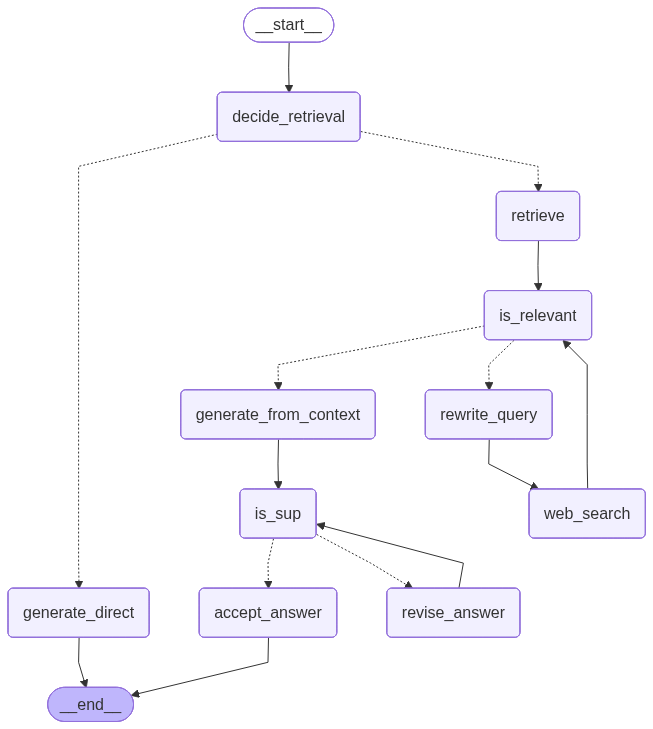

In [31]:
g = StateGraph(State)

g.add_node("decide_retrieval", decide_retrieval)
g.add_node("generate_direct", generate_direct)
g.add_node("retrieve", retrieve)

g.add_node("is_relevant", is_relevant)
g.add_node("generate_from_context", generate_from_context)

# ✅ new nodes (replace no_relevant_docs)
g.add_node("rewrite_query", rewrite_query_node)
g.add_node("web_search", web_search_node)

# ✅ new node for IsSUP check (not connected yet)
g.add_node("is_sup", is_sup)

# ✅ new nodes for answer acceptance and revision
g.add_node("accept_answer", accept_answer)
g.add_node("revise_answer", revise_answer)
# --------------------
# Edges
# --------------------

g.add_edge(START, "decide_retrieval")

g.add_conditional_edges(
    "decide_retrieval",
    route_after_decide,
    {
        "generate_direct": "generate_direct",
        "retrieve": "retrieve",
    },
)

g.add_edge("generate_direct", END)

# vector retrieval → relevance
g.add_edge("retrieve", "is_relevant")

# relevance router: if relevant → generate, else → rewrite_query
g.add_conditional_edges(
    "is_relevant",
    route_after_relevance,
    {
        "generate_from_context": "generate_from_context",
        "rewrite_query": "rewrite_query",
    },
)

# web fallback path
g.add_edge("rewrite_query", "web_search")
g.add_edge("web_search", "is_relevant")  # 🔁 circle back

# final
g.add_edge("generate_from_context", "is_sup")
g.add_conditional_edges(
    "is_sup",
    route_after_issup,
    (
        "accept_answer","accept_answer",
        "revise_answer","revise_answer"
    )
)
g.add_edge("accept_answer",END)
g.add_edge("revise_answer", "is_sup") 

app = g.compile()
app

In [32]:
result = app.invoke(
        {
            "question": 'Describe NexaAI’s company culture',
            "docs": [],
            "relevant_docs": [],
            "context": "",
            "answer": "",
            "issup": "",
            "evidence": [],
            "retries":0
        },
        config={"recursion_limit": 80},
    )

print("need_retrieval:", result.get("need_retrieval"))
print("#docs:", len(result.get("docs", [])))
print("#relevant_docs:", len(result.get("relevant_docs", [])))
print("issup:", result.get("issup"))
print("evidence:", result.get("evidence"))
print("answer:", result.get("answer"))

need_retrieval: True
#docs: 4
#relevant_docs: 3
issup: fully_supported
evidence: ['NexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace.', 'All employment decisions are made without discrimination.', 'Employees are encouraged to maintain a healthy work-life balance.']
answer: - NexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace.
- All employment decisions are made without discrimination.


In [33]:
print(result.get("retries"))

1


In [35]:
for doc in result['relevant_docs']:
    print(doc.page_content)
    print("*"*100)

NexaAI Solutions – Company Policies
HR Policies
NexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace.
All employment decisions are made without discrimination.

Equal opportunity employer

Bi-annual performance reviews

Clear career progression framework

Strict anti-harassment policy
Leave Policy
Employees are encouraged to maintain a healthy work-life balance.

Annual Leave: 18 working days per year

Sick Leave: 10 working days per year

Casual Leave: 6 working days per year

Maternity Leave: As per statutory norms

****************************************************************************************************
Founder
Aarav Mehta founded NexaAI after over 10 years of experience in enterprise data platforms and
cloud infrastructure.
He previously worked with global consulting firms where he led multiple large-scale digital
transformation projects.
Leadership Team
The leadership team brings experience across AI engineering, product manage